In [1]:
library(dplyr)
library(ggplot2)


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union




In [2]:
sorting_df <- readRDS("results_with_domains.rds")
results_df <- readRDS("Results Files/results_df_label_combined.rds")
dict_terms <- readRDS("Results Files/dict_terms_final_0510.rds")

In [11]:
head(sorting_df)

,issue,year,cor_with_ideo,cor_with_party,domain
,<chr>,<int>,<dbl>,<dbl>,<chr>
1,abortion4RC,1972,0.1223399,-0.05645443,Moral
2,abortion4RC,1974,NA,NA,Moral
3,abortion4RC,1976,0.1679825,-0.05667669,Moral
4,abortion4RC,1978,0.1645782,-0.08377976,Moral
5,abortion4RC,1980,0.2398392,-0.00604609,Moral
6,abortion4RC,1982,0.2297561,-0.05815082,Moral


In [14]:
sorting_df_new <-
    sorting_df %>%
    mutate(label = case_when(issue == "abortion4RC" ~ "Abortion",
                             issue %in% c("affirmact", "blacks_deservemore", "blacks_fair", "aid2blacks", 
                                          "blacks_specfav", "school_integ", "hard4blacks", "blacks_shldTry", 
                                          "civrights2fast", "blacks_poschange") ~ "Race",
                             issue == "healthinsur" ~ "Healthcare",
                             issue %in% c("gays_adoptkids", "gayer_military", "protect_homo") ~ "LGBTQ",
                             issue %in% c("fedspend_envi", "envi_reg") ~ "Environment",
                             issue %in% c("fedspend_poor", "fedspend_homeless", 
                                          "fedspend_welfare", "fedspend_foodstamp") ~ "Welfare & Poverty",
                             issue == "defense_spend" ~ "Military",
                             issue == "immigration_increase" ~ "Immigration",
                             issue == "fedspend_schools" ~ "Education",
                             issue %in% c("school_prayer", "bible_authRC") ~ "Religion",
                             issue == "fedspend_crimeRC" ~ "Crime",
                             issue == "gov_jobguar" ~ "Workers",
                             issue == "women_equals" ~ "Gender",
                             issue == "tax_wasteRC" ~ "Taxation",
                             issue == "fedspend_space" ~ "Space & Science",
                             TRUE ~ "Other")) %>%
      filter(label != "Other")

In [15]:
sorting_df_summary <-
    sorting_df_new %>%
    group_by(label, year) %>%
    summarise(cor_avg_ideo = mean(cor_with_ideo, na.rm=TRUE),
              cor_avg_party = mean(cor_with_party, na.rm=TRUE)) %>%
    ungroup() %>%
    mutate(cor_with_ideo_scaled = scale(cor_avg_ideo),   ## standardize
             cor_with_party_scaled = scale(cor_avg_party))

`summarise()` has grouped output by 'label'. You can override using the
`.groups` argument.


In [16]:
head(sorting_df_summary)

label,year,cor_avg_ideo,cor_avg_party,cor_with_ideo_scaled,cor_with_party_scaled
<chr>,<int>,<dbl>,<dbl>,"<dbl[,1]>","<dbl[,1]>"
Abortion,1972,0.1223399,-0.05645443,-0.95000074,-1.565014
Abortion,1974,NaN,NaN,NaN,NaN
Abortion,1976,0.1679825,-0.05667669,-0.59802512,-1.566559
Abortion,1978,0.1645782,-0.08377976,-0.62427801,-1.754987
Abortion,1980,0.2398392,-0.00604609,-0.04389804,-1.214562
Abortion,1982,0.2297561,-0.05815082,-0.12165460,-1.576808


In [29]:
results_df_final <-
   results_df %>%
   mutate(label = ifelse(label %in% c("ClimateChange", "Air Pollution", "Wildfires", "Disaster"), "Environment", label),
          label = ifelse(label %in% c("Racial", "Minority"), "Race", label),
          label = ifelse(label %in% c("CriminalJustice", "Police"), "Crime", label),
          label = ifelse(label %in% c("Catholicism", "Religion"), "Religion", label),
          label = ifelse(label %in% c("Space", "Science"), "Space & Science", label)) %>%
   filter(label %in% unique(sorting_df_summary$label)) %>%
   group_by(year, label, group) %>%
   summarise(value_avg = mean(value_avg, na.rm=TRUE)) %>%  ### Average within combined cateogry
   ungroup() %>%
   group_by(group) %>%
   mutate(value_avg_scaled = scale(value_avg)) %>%   ## standardize within ideology/party
   ungroup()

`summarise()` has grouped output by 'year', 'label'. You can override using the
`.groups` argument.


In [31]:
sort(unique(results_df_final$label))
sort(unique(sorting_df_summary$label))

[1] "Abortion"          "Crime"             "Education"        
 [4] "Environment"       "Gender"            "Healthcare"       
 [7] "Immigration"       "LGBTQ"             "Military"         
[10] "Race"              "Religion"          "Space & Science"  
[13] "Taxation"          "Welfare & Poverty" "Workers"

[1] "Abortion"          "Crime"             "Education"        
 [4] "Environment"       "Gender"            "Healthcare"       
 [7] "Immigration"       "LGBTQ"             "Military"         
[10] "Race"              "Religion"          "Space & Science"  
[13] "Taxation"          "Welfare & Poverty" "Workers"

In [33]:
library(tidyr)

combined <- 
   results_df_final %>%
    pivot_wider(names_from = group, values_from = c("value_avg", "value_avg_scaled")) %>%
   left_join(sorting_df_summary, by = c("label", "year"))

head(combined)

year,label,value_avg_ideology,value_avg_party,value_avg_scaled_ideology,value_avg_scaled_party,cor_avg_ideo,cor_avg_party,cor_with_ideo_scaled,cor_with_party_scaled
<dbl>,<chr>,<dbl>,<dbl>,"<dbl[,1]>","<dbl[,1]>",<dbl>,<dbl>,"<dbl[,1]>","<dbl[,1]>"
1980,Abortion,0.1803226,0.1737188,-0.5872190,-0.65700446,0.2398392,-0.00604609,-0.043898038,-1.2145618
1980,Crime,0.1684105,0.1894701,-0.8471226,-0.25498682,NaN,NaN,NaN,NaN
1980,Education,0.1901762,0.1879575,-0.3722291,-0.29359371,NaN,NaN,NaN,NaN
1980,Environment,0.1500167,0.1643581,-1.2484466,-0.89591628,NaN,NaN,NaN,NaN
1980,Gender,0.2301493,0.1958395,0.4999226,-0.09242263,0.2453611,0.04255592,-0.001316114,-0.8766675
1980,Healthcare,0.1562992,0.1604885,-1.1113718,-0.99467827,NaN,NaN,NaN,NaN


## Overall Trend

In [35]:
combined_all_wide <-
    combined %>%
    group_by(year) %>%
    summarise(
        year_pol_ideo  = mean(value_avg_scaled_ideology, na.rm = TRUE),
        year_sort_ideo = mean(cor_with_ideo_scaled, na.rm = TRUE),
        year_pol_party  = mean(value_avg_scaled_party, na.rm = TRUE),
        year_sort_party = mean(cor_with_party_scaled, na.rm = TRUE)
    ) %>%
    ungroup()

# correlations for annotation
cor_ideo  <- round(cor(combined_all_wide$year_pol_ideo,  combined_all_wide$year_sort_ideo,  use = "complete.obs"), 3)
cor_party <- round(cor(combined_all_wide$year_pol_party, combined_all_wide$year_sort_party, use = "complete.obs"), 3)

# long format for each dimension
long_ideo <- combined_all_wide %>%
    pivot_longer(cols = c(year_pol_ideo, year_sort_ideo),
                 names_to = "group", values_to = "value") %>%
    mutate(group = recode(group,
        "year_pol_ideo"  = "Politicization (discursive)",
        "year_sort_ideo" = "Ideological sorting"))

long_party <- combined_all_wide %>%
    pivot_longer(cols = c(year_pol_party, year_sort_party),
                 names_to = "group", values_to = "value") %>%
    mutate(group = recode(group,
        "year_pol_party"  = "Politicization (discursive)",
        "year_sort_party" = "Partisan sorting"))

In [36]:
# plots
p_ideo <- long_ideo %>%
    ggplot(aes(x = year, y = value, color = group)) +
    geom_point(alpha = 0.4, size = 1.5) +
    geom_smooth(method = "gam", se = TRUE) +
    annotate("text", x = Inf, y = Inf,
             label = paste0("r = ", cor_ideo),
             hjust = 1.1, vjust = 1.5, size = 3.5, color = "gray30") +
    scale_color_manual(values = c(
        "Politicization (discursive)" = "firebrick",
        "Ideological sorting"         = "steelblue")) +
    labs(title = "Ideology", y = "Mean z-score", x = "Year", color = NULL) +
    theme_minimal() +
    theme(legend.position = "bottom")

p_party <- long_party %>%
    ggplot(aes(x = year, y = value, color = group)) +
    geom_point(alpha = 0.4, size = 1.5) +
    geom_smooth(method = "gam", se = TRUE) +
    annotate("text", x = Inf, y = Inf,
             label = paste0("r = ", cor_party),
             hjust = 1.1, vjust = 1.5, size = 3.5, color = "gray30") +
    scale_color_manual(values = c(
        "Politicization (discursive)" = "firebrick",
        "Partisan sorting"            = "steelblue")) +
    labs(title = "Party", y = "Mean z-score", x = "Year", color = NULL) +
    theme_minimal() +
    theme(legend.position = "bottom")


Attaching package: ‘gridExtra’


The following object is masked from ‘package:dplyr’:

    combine


`geom_smooth()` using formula = 'y ~ s(x, bs = "cs")'
Warning message:
“Removed 29 rows containing non-finite outside the scale range
(`stat_smooth()`).”
Warning message:
“Removed 29 rows containing missing values or values outside the scale range
(`geom_point()`).”
`geom_smooth()` using formula = 'y ~ s(x, bs = "cs")'
Warning message:
“Removed 29 rows containing non-finite outside the scale range
(`stat_smooth()`).”
Warning message:
“Removed 29 rows containing missing values or values outside the scale range
(`geom_point()`).”


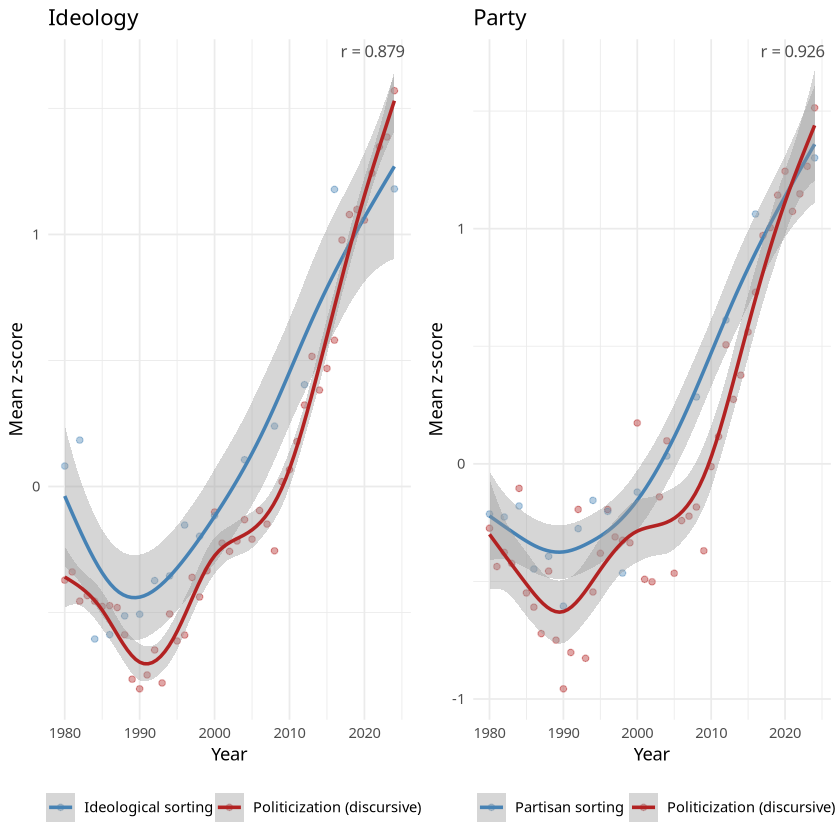

In [37]:
library(gridExtra)
grid.arrange(p_ideo, p_party, ncol = 2)

In [38]:
g <- arrangeGrob(p_ideo, p_party, ncol = 2)
ggsave("overall_trend.png", g, width = 8, height = 8.5, dpi = 300)

`geom_smooth()` using formula = 'y ~ s(x, bs = "cs")'
Warning message:
“Removed 29 rows containing non-finite outside the scale range
(`stat_smooth()`).”
Warning message:
“Removed 29 rows containing missing values or values outside the scale range
(`geom_point()`).”
`geom_smooth()` using formula = 'y ~ s(x, bs = "cs")'
Warning message:
“Removed 29 rows containing non-finite outside the scale range
(`stat_smooth()`).”
Warning message:
“Removed 29 rows containing missing values or values outside the scale range
(`geom_point()`).”


## Trends by Issue

In [39]:
combined_ideo <- combined %>%
  group_by(label) %>%
  arrange(year) %>%
  mutate(
    first_common_year = min(year[!is.na(value_avg_ideology) & !is.na(cor_avg_ideo)]),
    last_common_year  = max(year[!is.na(value_avg_ideology) & !is.na(cor_avg_ideo)]),
    in_common_window = year >= first_common_year & year <= last_common_year,
    cosine_base  = value_avg_scaled_ideology[year == first_common_year],
    sorting_base = cor_with_ideo_scaled[year == first_common_year],
    cosine_rebase  = value_avg_scaled_ideology - cosine_base,
    sorting_rebase = cor_with_ideo_scaled - sorting_base
  ) %>%
  ungroup() %>%
  mutate(year0 = year - 1980)

In [40]:
combined_ideo %>%
    filter(label == "LGBTQ")

year,label,value_avg_ideology,value_avg_party,value_avg_scaled_ideology,value_avg_scaled_party,cor_avg_ideo,cor_avg_party,cor_with_ideo_scaled,cor_with_party_scaled,first_common_year,last_common_year,in_common_window,cosine_base,sorting_base,cosine_rebase,sorting_rebase,year0
<dbl>,<chr>,<dbl>,<dbl>,"<dbl[,1]>","<dbl[,1]>",<dbl>,<dbl>,"<dbl[,1]>","<dbl[,1]>",<dbl>,<dbl>,<lgl>,<dbl>,<dbl>,"<dbl[,1]>","<dbl[,1]>",<dbl>
1980,LGBTQ,0.2047399,0.1694181,-0.054470132,-0.76677023,NaN,NaN,NaN,NaN,1988,2024,FALSE,0.005925142,-0.2885458,-0.06039527,NaN,0
1981,LGBTQ,0.1779209,0.1440135,-0.639620921,-1.41516566,NA,NA,NA,NA,1988,2024,FALSE,0.005925142,-0.2885458,-0.64554606,NA,1
1982,LGBTQ,0.1815216,0.1500541,-0.561059420,-1.26099251,NaN,NaN,NaN,NaN,1988,2024,FALSE,0.005925142,-0.2885458,-0.56698456,NaN,2
1983,LGBTQ,0.2068476,0.1599521,-0.008484974,-1.00836712,NA,NA,NA,NA,1988,2024,FALSE,0.005925142,-0.2885458,-0.01441012,NA,3
1984,LGBTQ,0.1950645,0.1692311,-0.265572602,-0.77154277,NaN,NaN,NaN,NaN,1988,2024,FALSE,0.005925142,-0.2885458,-0.27149774,NaN,4
1985,LGBTQ,0.1836931,0.1367691,-0.513680199,-1.60006138,NA,NA,NA,NA,1988,2024,FALSE,0.005925142,-0.2885458,-0.51960534,NA,5
1986,LGBTQ,0.1905062,0.1282211,-0.365028117,-1.81823000,NaN,NaN,NaN,NaN,1988,2024,FALSE,0.005925142,-0.2885458,-0.37095326,NaN,6
1987,LGBTQ,0.2107136,0.1460549,0.075865515,-1.36306287,NA,NA,NA,NA,1988,2024,FALSE,0.005925142,-0.2885458,0.06994037,NA,7
1988,LGBTQ,0.2075080,0.1668557,0.005925142,-0.83216841,0.2081144,0.0659987,-0.288545846,-0.71368688,1988,2024,TRUE,0.005925142,-0.2885458,0.00000000,0.0000000,8


In [41]:
library(broom)

# For politicization
slopes_pol <- combined_ideo %>%
  filter(!is.na(cosine_rebase)) %>%
  group_by(label) %>%
  filter(year >= first_common_year & year <= last_common_year) %>%
  do(tidy(lm(cosine_rebase ~ year, data = .))) %>%
  filter(term == "year") %>%
  select(label, slope_pol = estimate, se_pol = std.error)

# For sorting
slopes_sort <- combined_ideo %>%
  filter(!is.na(sorting_rebase)) %>%
  group_by(label) %>%
  filter(year >= first_common_year & year <= last_common_year) %>%
  do(tidy(lm(sorting_rebase ~ year, data = .))) %>%
  filter(term == "year") %>%
  select(label, slope_sort = estimate, se_sort = std.error)

# Combine
slopes <- left_join(slopes_pol, slopes_sort, by = "label") %>%
  mutate(slope_diff = slope_pol - slope_sort) %>%
  arrange(desc(slope_diff))

slopes

Warning message:
“Using one column matrices in `filter()` was deprecated in dplyr 1.1.0.
ℹ Please use one dimensional logical vectors instead.”


label,slope_pol,se_pol,slope_sort,se_sort,slope_diff
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Immigration,0.109375482,0.007719233,0.048092971,0.024328529,0.061282512
LGBTQ,0.075053044,0.006029342,0.027725484,0.007598308,0.047327560
Race,0.054259588,0.005168429,0.039013913,0.010183743,0.015245675
Education,0.049352327,0.003603496,0.038316581,0.009470789,0.011035746
Abortion,0.064358370,0.006664365,0.058283671,0.010021053,0.006074699
Workers,0.048328995,0.005107245,0.042439722,0.009466373,0.005889273
Religion,0.062725305,0.004437118,0.059272186,0.005727613,0.003453119
Crime,0.056227909,0.005530695,0.059372917,0.017397419,-0.003145008
Gender,-0.005431409,0.006777318,-0.001661015,0.014764103,-0.003770393


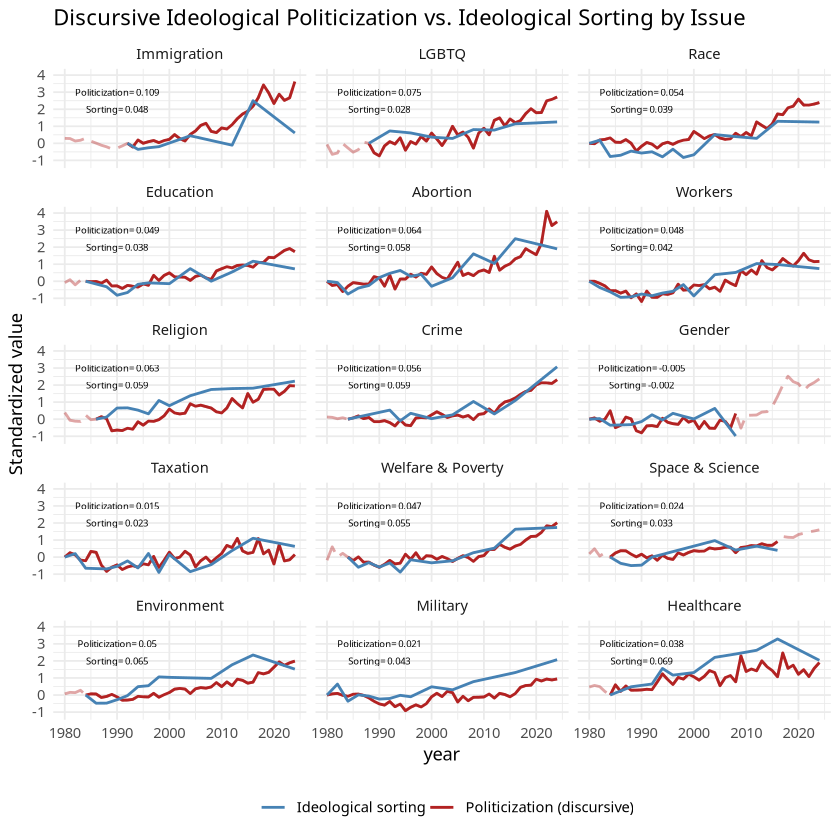

In [42]:
## Standardized and plot the two trends together

combined_ideo %>%
  ggplot(aes(x = year)) +
  geom_line(aes(y = cosine_rebase, color = "Politicization (discursive)"),
            linewidth = 0.8, alpha = 0.4, linetype = "longdash") +
  geom_line(data = filter(combined_ideo, in_common_window),
            aes(y = cosine_rebase, 
                color = "Politicization (discursive)"), 
            linewidth = 0.8) +
  geom_line(data = filter(combined_ideo, in_common_window & !is.na(sorting_rebase)),
            aes(y = sorting_rebase, 
                color = "Ideological sorting"), 
            linewidth = 0.8) +
  geom_text(data = slopes, 
            aes(label=paste("Sorting=", round(slope_sort, digits = 3))), x = 1990, y = 2, size = 2) +
  geom_text(data = slopes, 
            aes(label=paste("Politicization=", round(slope_pol, digits = 3))), x = 1990, y =3, size = 2) +
  facet_wrap(~factor(label, levels = slopes$label), ncol=3) +
  scale_color_manual(values = c("Politicization (discursive)" = "firebrick",
                                 "Ideological sorting" = "steelblue")) +
  labs(title = "Discursive Ideological Politicization vs. Ideological Sorting by Issue",
       y = "Standardized value", color = NULL) +
  theme_minimal() +
  theme(legend.position = "bottom")

In [43]:
ggsave("politicization_comapre_ideo.png")

Saving 6.67 x 6.67 in image


In [46]:
combined_party <- combined %>%
  group_by(label) %>%
  arrange(year) %>%
  mutate(
    first_common_year = min(year[!is.na(value_avg_party) & !is.na(cor_avg_party)]),
    last_common_year  = max(year[!is.na(value_avg_party) & !is.na(cor_avg_party)]),
    in_common_window = year >= first_common_year & year <= last_common_year,
    cosine_base  = value_avg_scaled_party[year == first_common_year],
    sorting_base = cor_with_party_scaled[year == first_common_year],
    cosine_rebase  = value_avg_scaled_party - cosine_base,
    sorting_rebase = cor_with_party_scaled - sorting_base
  ) %>%
  ungroup()

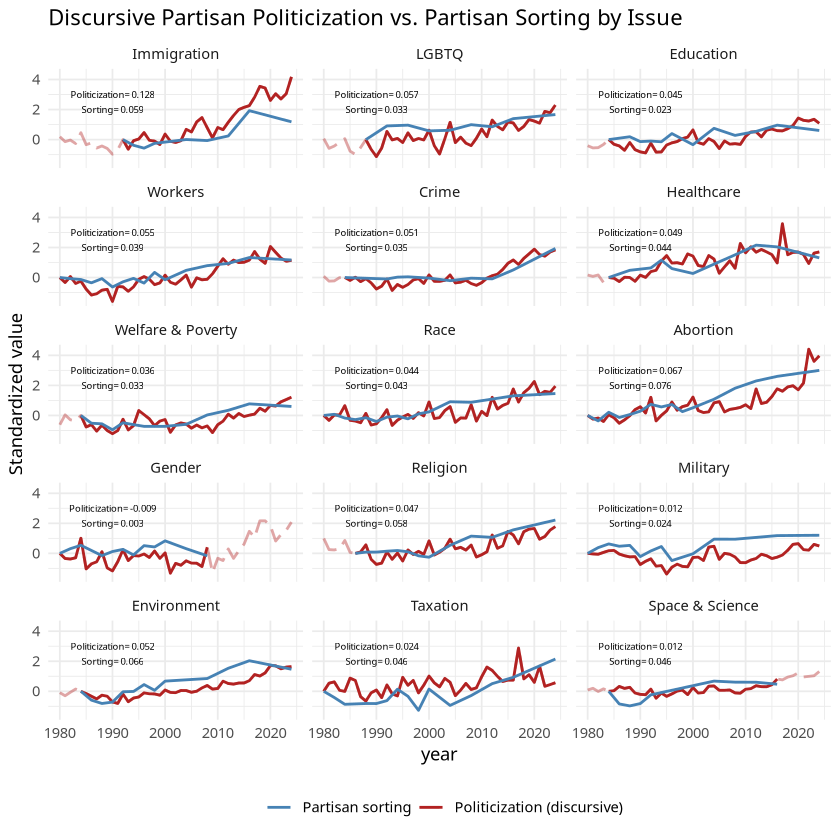

In [47]:
# For politicization
slopes_pol <- combined_party %>%
  filter(!is.na(cosine_rebase)) %>%
  group_by(label) %>%
  filter(year >= first_common_year & year <= last_common_year) %>%
  do(tidy(lm(cosine_rebase ~ year, data = .))) %>%
  filter(term == "year") %>%
  select(label, slope_pol = estimate, se_pol = std.error)

# For sorting
slopes_sort <- combined_party %>%
  filter(!is.na(sorting_rebase)) %>%
  group_by(label) %>%
  filter(year >= first_common_year & year <= last_common_year) %>%
  do(tidy(lm(sorting_rebase ~ year, data = .))) %>%
  filter(term == "year") %>%
  select(label, slope_sort = estimate, se_sort = std.error)

# Combine
slopes <- left_join(slopes_pol, slopes_sort, by = "label") %>%
  mutate(slope_diff = slope_pol - slope_sort) %>%
  arrange(desc(slope_diff))


## Standardized and plot the two trends together

combined_party %>%
  ggplot(aes(x = year)) +
  geom_line(aes(y = cosine_rebase, color = "Politicization (discursive)"),
            linewidth = 0.8, alpha = 0.4, linetype = "longdash") +
  geom_line(data = filter(combined_party, in_common_window),
            aes(y = cosine_rebase, 
                color = "Politicization (discursive)"), 
            linewidth = 0.8) +
  geom_line(data = filter(combined_party, in_common_window & !is.na(sorting_rebase)),
            aes(y = sorting_rebase, 
                color = "Partisan sorting"), 
            linewidth = 0.8) +
  geom_text(data = slopes, 
            aes(label=paste("Sorting=", round(slope_sort, digits = 3))), x = 1990, y = 2, size = 2) +
  geom_text(data = slopes, 
            aes(label=paste("Politicization=", round(slope_pol, digits = 3))), x = 1990, y =3, size = 2) +
  facet_wrap(~factor(label, levels = slopes$label), ncol=3) +
  scale_color_manual(values = c("Politicization (discursive)" = "firebrick",
                                 "Partisan sorting" = "steelblue")) +
  labs(title = "Discursive Partisan Politicization vs. Partisan Sorting by Issue",
       y = "Standardized value", color = NULL) +
  theme_minimal() +
  theme(legend.position = "bottom")

In [48]:
ggsave("politicization_comapre_party.png")

Saving 6.67 x 6.67 in image
